# Week 5: Unsupervised Learning - K-Means Live Session

**Welcome!** In this notebook, you'll follow along with the instructor to build your first K-Means clustering pipeline.

**Dataset:** Mall Customers  
**Goal:** Segment customers into groups based on income and spending patterns

---

## What You'll Learn Today

By the end of this session, you'll be able to:
1. ✅ Build a complete K-Means clustering pipeline
2. ✅ Use the elbow method to choose optimal K
3. ✅ Calculate and interpret silhouette scores
4. ✅ Visualize clusters in 2D scatter plots
5. ✅ Interpret clusters in business terms
6. ✅ Understand when to scale features

---

## 📝 How to Use This Notebook

**Scaffolding Level:** 50% provided (midpoint independence)

**Your task:**
1. 👂 **Listen** to the instructor explain each concept
2. 🔨 **Fill in** the TODO sections (hints provided)
3. ▶️ **Run** the cell and verify output
4. 👀 **Observe** the results
5. ❓ **Ask questions** if anything is unclear

**Remember:** Unsupervised learning has NO labels - we discover patterns!

---

Let's begin!

---

## Step 1: Setup & Imports

**What we're doing:** Importing all the tools we need for K-Means clustering

**Notice:** Similar pattern to supervised learning, but no train/test split!

**Listen to the instructor explain each import, then run this cell:**

In [2]:
# Week 5: K-Means Clustering Pipeline
# Mall Customers Dataset

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# K-Means clustering (NEW!)
from sklearn.cluster import KMeans

# Evaluation metrics (NEW!)
from sklearn.metrics import silhouette_score

# Visualization settings
%matplotlib inline
sns.set_style('whitegrid')

print("✅ All imports successful!")

✅ All imports successful!


**Expected Output:** `✅ All imports successful!`

**If you see this, you're ready to go!** ✓

---

### 💡 New Imports from Weeks 1-4:
- `KMeans` - Our clustering algorithm
- `silhouette_score` - Measures clustering quality
- **No classification metrics** - unsupervised learning has no labels!

---

## Step 2: Load and Explore Data

**What we're doing:** Loading the Mall Customers dataset and understanding its structure

**Dataset context:**
- 200 mall customers
- Features: Age, Annual Income, Spending Score
- **No target variable** - we'll discover groups!

**Listen to the instructor, then run this cell:**

In [3]:
# Load the Mall Customers dataset
print("Loading Mall Customers dataset...")
df = pd.read_csv('../data/Mall_Customers.csv')

# Explore the data
print(f"✅ Data loaded successfully!")
print(f"\nDataset Information:")
print(f"  Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Loading Mall Customers dataset...
✅ Data loaded successfully!

Dataset Information:
  Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Check for missing values and get summary statistics
print("Missing values:")
print(df.isnull().sum())
print("\nSummary statistics:")
df.describe()

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Summary statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 📊 Understanding the Data:

**Features:**
- `CustomerID`: Unique identifier (won't use for clustering)
- `Gender`: Male/Female (categorical - won't use today)
- `Age`: Customer age
- `Annual Income (k$)`: Yearly income in thousands
- `Spending Score (1-100)`: Mall's internal rating of spending behavior

**Questions to think about (instructor will discuss):**
- What patterns might exist in this data?
- How could customer segments help a business?

---

## Step 3: Select Features for Clustering

**Your first TODO!** Select the features we'll use for clustering.

**Listen to the instructor, then complete and run:**

In [5]:
# TODO: Select Income and Spending Score as features
# Hint: Use df[['column1', 'column2']].values
# We're using 2 features for easy 2D visualization

X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print(f"✅ Features selected!")
print(f"Shape of X: {X.shape}")  # Expected: (200, 2)
print(f"\nFirst 5 samples:")
print(X[:5])

✅ Features selected!
Shape of X: (200, 2)

First 5 samples:
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


**Expected output:** `Shape: (200, 2)` - 200 customers, 2 features

**Why just 2 features?**
- Easy to visualize in 2D scatter plot
- In practice, you'd use more features (age, visit frequency, etc.)
- Same clustering process applies!

---

## Step 4: Feature Scaling ⭐ **CRITICAL**

**NEW concept:** K-Means uses Euclidean distance, so features must be on similar scales!

**Your second TODO!** Scale the features.

**Listen to the instructor explain StandardScaler, then complete and run:**

In [6]:
# Check original feature scales
print("Original feature ranges:")
print(f"  Income: {X[:, 0].min():.1f} - {X[:, 0].max():.1f}")
print(f"  Spending: {X[:, 1].min():.1f} - {X[:, 1].max():.1f}")

Original feature ranges:
  Income: 15.0 - 137.0
  Spending: 1.0 - 99.0


In [7]:
# TODO: Create StandardScaler and scale the features
# Hint: Create scaler, then use fit_transform()
# Expected: X_scaled with mean≈0, std≈1

# Create scaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled!")
print(f"\nAfter scaling (first feature):")
print(f"  Mean: {X_scaled[:, 0].mean():.2f}")  # Should be ~0
print(f"  Std:  {X_scaled[:, 0].std():.2f}")   # Should be ~1

✅ Features scaled!

After scaling (first feature):
  Mean: -0.00
  Std:  1.00


**Expected output:** Mean ≈ 0.00, Std ≈ 1.00

**Key understanding:**
- `fit_transform()` - learns statistics AND transforms
- For unsupervised learning, we fit_transform on all data
- No train/test split needed - we're discovering patterns!

**Critical:** Always scale before K-Means!

---

## Step 5: The Elbow Method - Choosing K ⭐ **CRITICAL**

**Big question:** How many clusters should we create?

**The elbow method:**
1. Try different values of K (2, 3, 4, 5...)
2. Calculate inertia (sum of squared distances)
3. Plot K vs inertia
4. Look for the "elbow" - where adding clusters stops helping much

**Your third TODO!** Implement the elbow method.

**Listen to the instructor, then complete and run:**

In [8]:
# TODO: Implement elbow method
# Steps:
# 1. Create empty list for inertias
# 2. Loop through K values 2 to 8
# 3. For each K: create KMeans, fit, store inertia

# Create list to store inertias
inertias = []

# Define K range to test
K_range = range(2, 8)  # Try K = 2 to 8

# TODO: Loop through K values
for k in K_range:
    # TODO: Create K-Means model
    # Hint: KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # TODO: Fit the model
    kmeans.fit(X_scaled)
    
    # TODO: Store the inertia
    # Hint: kmeans.inertia_
    inertias.append(kmeans.inertia_)
    
    print(f"K={k}: inertia={kmeans.inertia_:.2f}")

print("\n✅ Elbow method calculations complete!")

K=2: inertia=269.69
K=3: inertia=157.70
K=4: inertia=108.92
K=5: inertia=65.57
K=6: inertia=55.06
K=7: inertia=44.86

✅ Elbow method calculations complete!


**Expected output:** Inertia values decreasing as K increases

**What is inertia?**
- Sum of squared distances from points to their cluster center
- Lower inertia = more compact clusters
- But we don't want K=200 (each point its own cluster!)
- Look for diminishing returns - the "elbow"

In [9]:
#!pip install "git+https://github.com/lwgray/yellowbrick.git@update-deps-local"

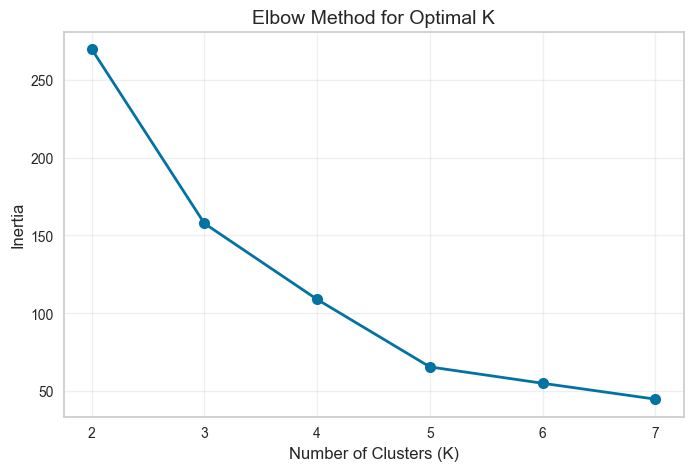

In [10]:
# TODO: Create elbow plot
# Hint: plt.plot(K_range, inertias, 'bo-')

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

### 💬 Discuss with Instructor:

**Where is the elbow?** Look at the plot - where does the curve start to flatten?

**Typical elbow shape:**
```
Inertia
    │ ●
    │  \
    │   \
    │    ●___     ← ELBOW here
    │        \___●___●
    └──────────────────> K
      2  3  4  5  6  7  8
```

**Based on the plot, what K would you choose?** ____

---

## Step 6: Fit K-Means with Optimal K

**Decision:** Let's go with K=5 (adjust based on your elbow plot!)

**Your fourth TODO!** Fit K-Means with K=5.

**Listen to the instructor, then complete and run:**

In [11]:
# TODO: Create and fit K-Means with K=5
# Hint: KMeans(n_clusters=5, random_state=42, n_init=10)

# Create K-Means model
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)

# TODO: Fit the model and get cluster assignments
# Hint: Use fit_predict() to fit and get labels in one step
clusters = kmeans_final.fit_predict(X_scaled)

print("✅ K-Means model trained!")
print(f"\nCluster assignments (first 20): {clusters[:20]}")

# Check cluster distribution
print(f"\nCluster distribution:")
print(pd.Series(clusters).value_counts().sort_index())

✅ K-Means model trained!

Cluster assignments (first 20): [4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2]

Cluster distribution:
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


**Expected output:** Each customer assigned to cluster 0, 1, 2, 3, or 4

**What just happened?**
- K-Means found 5 cluster centers
- Assigned each customer to nearest center
- Cluster numbers (0-4) are arbitrary labels

---

## Step 7: Calculate Silhouette Score

**How good is our clustering?** Let's check with silhouette score!

**Your fifth TODO!** Calculate silhouette score.

**Listen to the instructor, then complete and run:**

In [12]:
# TODO: Calculate silhouette score
# Hint: silhouette_score(X_scaled, clusters)
# Expected: A number between -1 and 1

sil_score = silhouette_score(X_scaled, clusters)

print("=" * 60)
print("SILHOUETTE SCORE")
print("=" * 60)
print(f"\nSilhouette Score: {sil_score:.3f}")
print(f"\nInterpretation:")

if sil_score > 0.7:
    print("  ✅ Excellent clustering! (>0.7)")
elif sil_score > 0.5:
    print("  ✅ Good clustering (0.5-0.7)")
elif sil_score > 0.25:
    print("  ⚠️  Reasonable clustering (0.25-0.5)")
else:
    print("  ❌ Weak clustering (<0.25) - consider different K")

print("\n" + "=" * 60)

SILHOUETTE SCORE

Silhouette Score: 0.555

Interpretation:
  ✅ Good clustering (0.5-0.7)



**What is silhouette score?**
- Measures how similar points are to their own cluster vs other clusters
- Range: -1 (wrong clustering) to +1 (perfect clustering)
- **>0.7:** Excellent
- **0.5-0.7:** Good
- **<0.5:** Weak (maybe wrong K or no clear clusters)

**Our score confirms K=5 is a good choice!** ✓

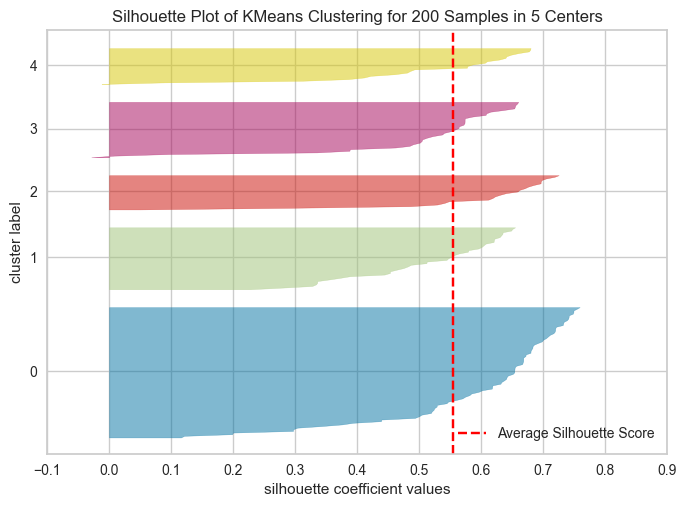

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [13]:
from yellowbrick.cluster import SilhouetteVisualizer
model = KMeans(n_clusters=5, random_state=42, n_init=10)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick',force_model=True)  # Create visualizer with model and colors
visualizer.fit(X_scaled)  # Fit the data to the visualizer
visualizer.show()  # Finalize and render the figure

---

## Step 8: Visualize Clusters ⭐ **THE PAYOFF!**

**Now let's SEE the clusters!**

**Your sixth TODO!** Create a scatter plot colored by cluster.

**Listen to the instructor, then complete and run:**

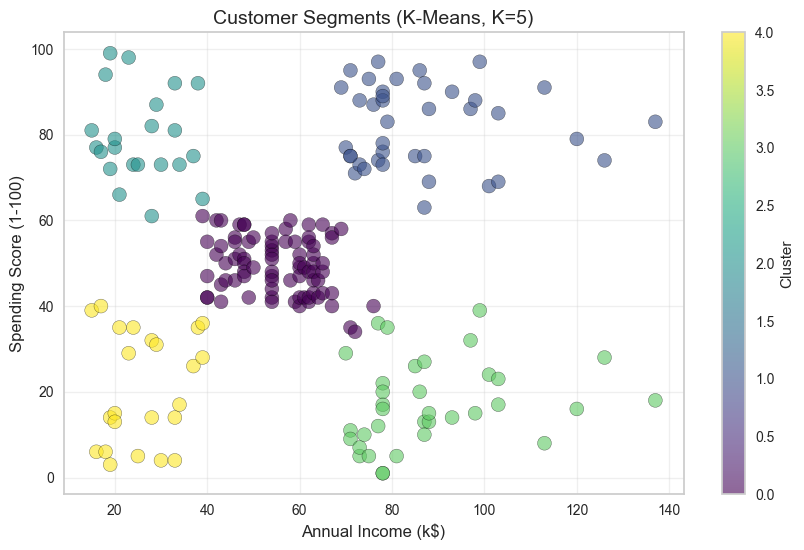

In [14]:
# Add cluster labels to dataframe
df['Cluster'] = clusters

# TODO: Create scatter plot
# Hint: plt.scatter(x, y, c=colors, cmap='viridis')

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],  # Spending Score column
    c=df['Cluster'],
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black'
)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Customer Segments (K-Means, K=5)', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

**Look at the clusters!** Each color represents a distinct customer segment.

**Questions to think about:**
- Do the clusters make sense visually?
- Are they well-separated?
- What patterns do you notice?

---

## Step 9: Interpret Clusters ⭐ **CRITICAL**

**This is where clustering becomes valuable!**

Technical clustering is done. Now: **What do these clusters MEAN for business?**

**Listen to the instructor analyze cluster centers:**

In [15]:
# Get cluster centers (in original scale)
centers_scaled = kmeans_final.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

# Create summary DataFrame
cluster_summary = pd.DataFrame(
    centers_original,
    columns=['Income', 'Spending Score'],
    index=[f'Cluster {i}' for i in range(5)]
)

print("=" * 60)
print("CLUSTER CENTERS (Original Scale)")
print("=" * 60)
print(cluster_summary.round(1))
print("\n" + "=" * 60)

CLUSTER CENTERS (Original Scale)
           Income  Spending Score
Cluster 0    55.3            49.5
Cluster 1    86.5            82.1
Cluster 2    25.7            79.4
Cluster 3    88.2            17.1
Cluster 4    26.3            20.9



### 💬 Cluster Interpretation (Discuss with Instructor):

**For each cluster, identify:**
1. Income level (Low/Medium/High)
2. Spending level (Low/Medium/High)
3. Business-friendly name
4. Marketing strategy

**Example interpretation:**

**Cluster 0:** _________________
- Income: _______  Spending: _______
- Name: ___________________
- Strategy: ___________________

**Cluster 1:** _________________
- Income: _______  Spending: _______
- Name: ___________________
- Strategy: ___________________

**Cluster 2:** _________________
- Income: _______  Spending: _______
- Name: ___________________
- Strategy: ___________________

**Cluster 3:** _________________
- Income: _______  Spending: _______
- Name: ___________________
- Strategy: ___________________

**Cluster 4:** _________________
- Income: _______  Spending: _______
- Name: ___________________
- Strategy: ___________________

---

## 🎉 Congratulations!

You've just built your first complete K-Means clustering pipeline!

**What you accomplished:**
1. ✅ Loaded and explored customer data
2. ✅ Scaled features (CRITICAL for K-Means)
3. ✅ Used elbow method to choose optimal K
4. ✅ Fit K-Means model and assigned clusters
5. ✅ Calculated silhouette score
6. ✅ Visualized clusters in 2D
7. ✅ Interpreted clusters in business terms

---

## 💡 Key Takeaways

**Remember these critical concepts:**

1. **No labels in unsupervised learning:**
   - We discover patterns, not predict targets
   - Interpretation is subjective but valuable

2. **Always scale before K-Means:**
   - K-Means uses Euclidean distance
   - Unscaled features bias the algorithm
   - Use StandardScaler!

3. **Elbow method helps choose K:**
   - Plot K vs inertia
   - Look for the "elbow"
   - Combine with business judgment

4. **Silhouette score validates clustering:**
   - >0.7 = Excellent
   - 0.5-0.7 = Good
   - <0.5 = Weak (try different K)

5. **Interpretation is key:**
   - Clusters are useless without business meaning
   - Name clusters, suggest strategies
   - This is what makes you valuable!

---

## 🚀 Next Steps

**Up next: PCA visualization!**
- You'll see how to visualize high-dimensional data
- MNIST digits: 784 dimensions → 2D!

**Then: Pair programming!**
- "Cluster Detective" exercise
- Practice cluster interpretation on Wine dataset

**Tonight's homework:**
- Build K-Means pipeline on Wine dataset (40% scaffolding)
- Apply all skills learned today

---

## ❓ Reflection Questions

**Take a moment to think about:**

1. How is unsupervised learning different from supervised learning?

2. Why is feature scaling critical for K-Means?

3. What was the most surprising cluster you found?

4. How would you explain the elbow method to a non-technical stakeholder?

5. In your domain, what could you cluster?

---

**Excellent work! Ready for PCA?** 🎓

---

*Week 5 K-Means Live Session v1.0 | February 2026*